In [67]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
# import lib_plot

from lib_fitting import lin_fit
from lib_equations import trapezoidal, Simpson, Gauss_Leg


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Consider the integral

$$
\int_{0}^{1} dx \frac{4}{1 + x^2} = \pi
$$

and study the accuracy of the solution as function of $\Delta x$ for the trapezoidal, Simpson's and 2-point Gauss-Legendre quadrature. Using the analytic knowledge of the scaling of the error, predict (for all methods) for which value of $N$ the absolute error is $10^{-6}$ and verify it with the data.

# **2-Points Gauss Quadrature**

In [68]:
# Params
a = -1
b = 1
dx_ = 1e-6

func = np.exp

res = Gauss_Leg(func, a, b, dx_)

# Results
print(f'a = {a}')
print(f'b = {b}\n')
true = func(b) - func(a)

print('true =', true)
print('I{a, b} =', res)
print('\ndiff =', abs(true - res))


a = -1
b = 1

true = 2.3504023872876028
I{a, b} = 2.350402387287603

diff = 4.440892098500626e-16


# **Comparison between the different methods**

In [69]:
func = lambda x: 4 / (1 + x**2)

a, b = (0, 1)
dx_ = 1e-5

res_t = trapezoidal(func, a, b, dx_)
res_s = Simpson(func, a, b, dx_)
res_g = Gauss_Leg(func, a, b, dx_)
true  = np.pi

diff_t = abs(true - res_t)
diff_s = abs(true - res_s )
diff_g = abs(true - res_g )

# Results
print(f'a = {a}')
print(f'b = {b}')
print('True =', true)

print('\n\nTrapezoidal\'s Rule:')
print('\nI_t =', res_t)
print('diff =',diff_t)

print('\n\nSimpson\'s Rule:')
print('\nI_s =', res_s)
print('diff =',diff_s)

print('\n\nN_trap-point Gauss-Legendre quadrature\'s Rule:')
print('\nI_g =', res_g)
print('diff =',diff_g)


a = 0
b = 1
True = 3.141592653589793


Trapezoidal's Rule:

I_t = 3.141592653573126
diff = 1.66671121348827e-11


Simpson's Rule:

I_s = 3.141592653589794
diff = 8.881784197001252e-16


N_trap-point Gauss-Legendre quadrature's Rule:

I_g = 3.1415926535897936
diff = 4.440892098500626e-16


## **Analitic evaluation of $N$ value needed to reach $\epsilon=10^{-6}$**

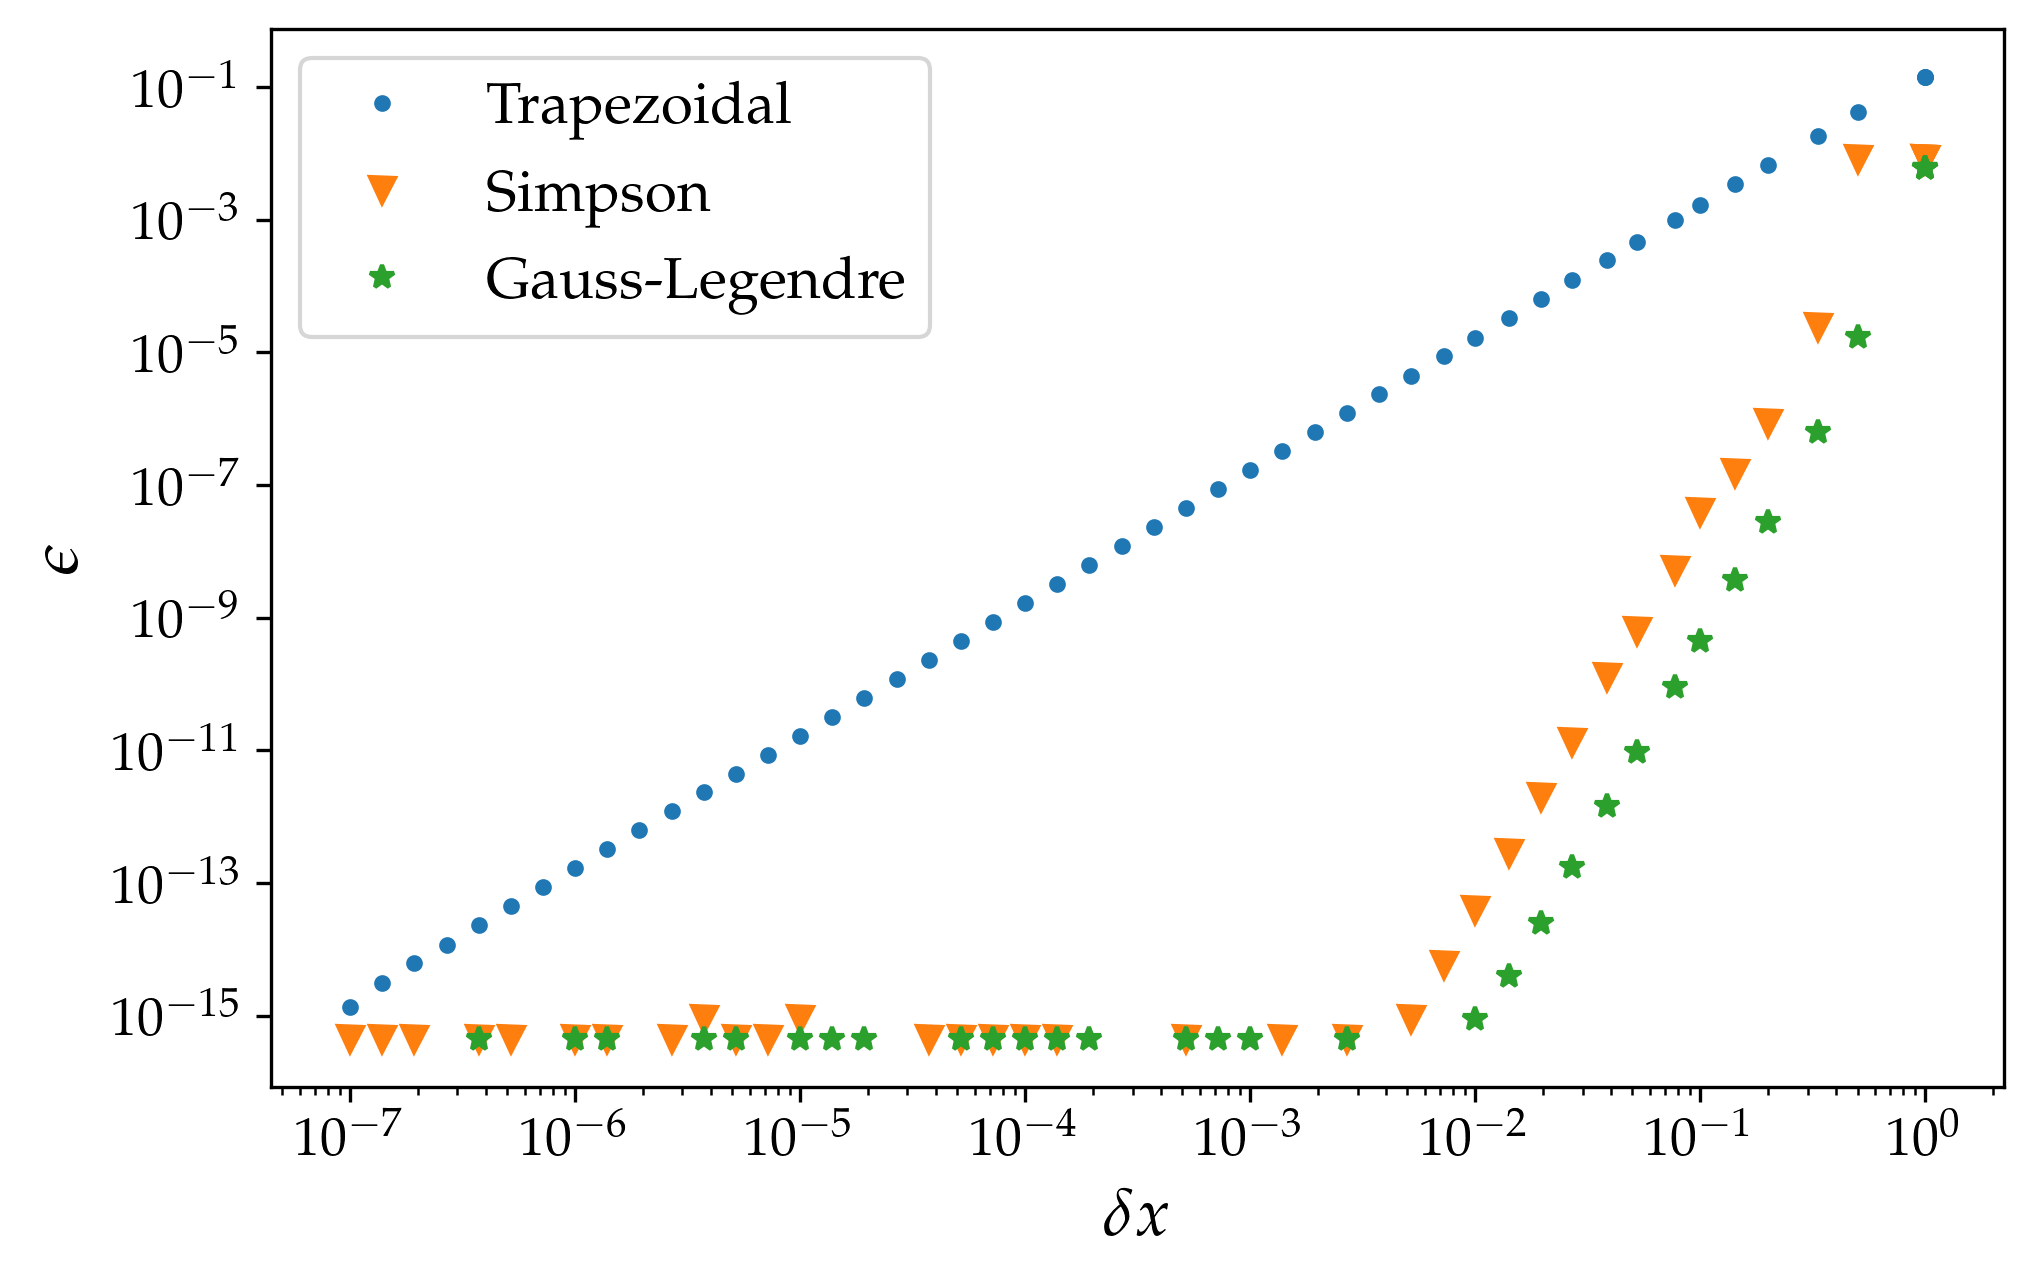

In [70]:
# Params
dx_span = np.logspace(-7, 0, 50)
true_dx_ls = [[],[],[]]

eps = 1e-14 
error = [[], [], []]

for dx_ in dx_span:
    for i in range(3):
        gr_spec = [['Trapezoidal', '.', trapezoidal], 
                [ 'Simpson', 'v', Simpson],
                [ 'Gauss-Legendre', '*', Gauss_Leg]]
        
        f_int = gr_spec[i][2]
        res = f_int(func, a, b, dx=dx_, r_true_dx=True)
        true_dx_ls[i].append(res[1])
        err = np.abs(res[0] - true)
        error[i].append(err)
true_dx = np.array(true_dx_ls)

error = np.array(error)
N_span = ((b-a) / true_dx)

N_span = N_span[0]

plt.figure(figsize=(7,4.5))
for i in range(3):
    plt.loglog(true_dx[0], error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$\delta x$')
plt.ylabel(r'$\epsilon$')
plt.legend()
plt.tight_layout()
plt.savefig('plots/conf_3mth')
plt.show()


dof = 47

a = 2.00e+00 +/- 6.991e-02
b = -7.93e-01 +/- 2.781e-01

Chi2 = 0.01
p-val = 1.00


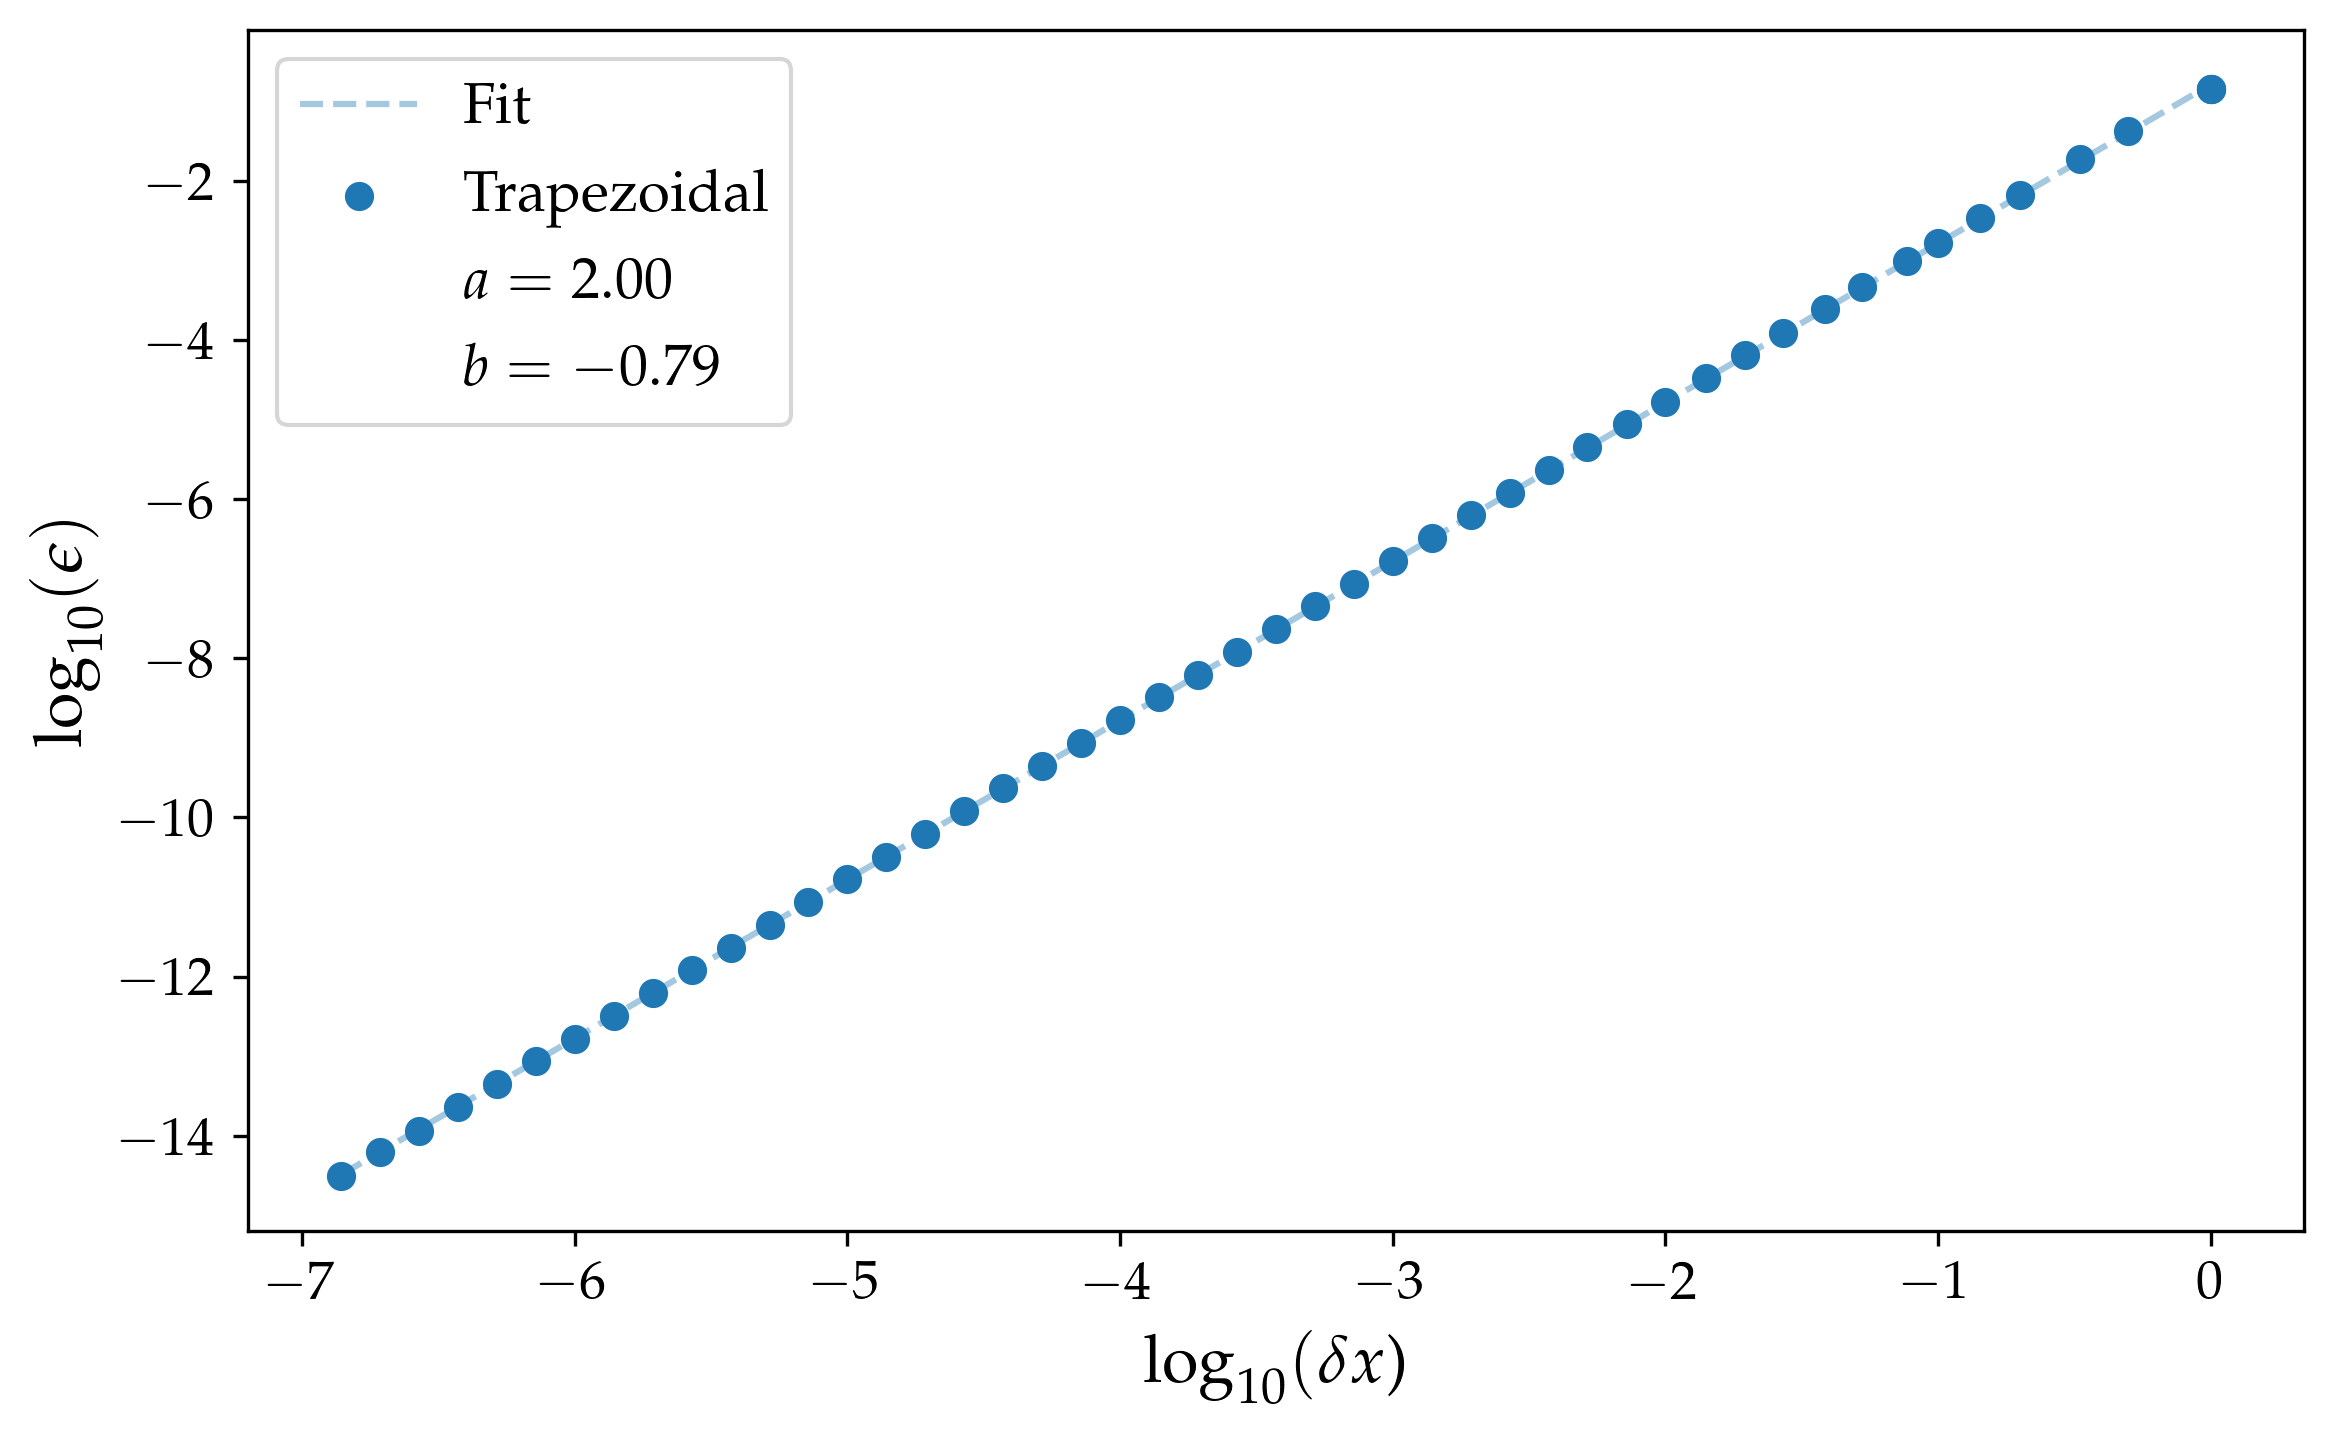

In [71]:
i = 0 
cut = 1
dx, eps_dx = (true_dx[i][cut:], error[i][cut:])

res_t = lin_fit(np.log10(dx), np.log10(eps_dx),
        mar='o', col='C0', name_points='Trapezoidal',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/FitTrap_2')

dof = 8

a = 6.01e+00 +/- 8.006e-01
b = -1.39e+00 +/- 1.141e+00

Chi2 = 0.00
p-val = 1.00


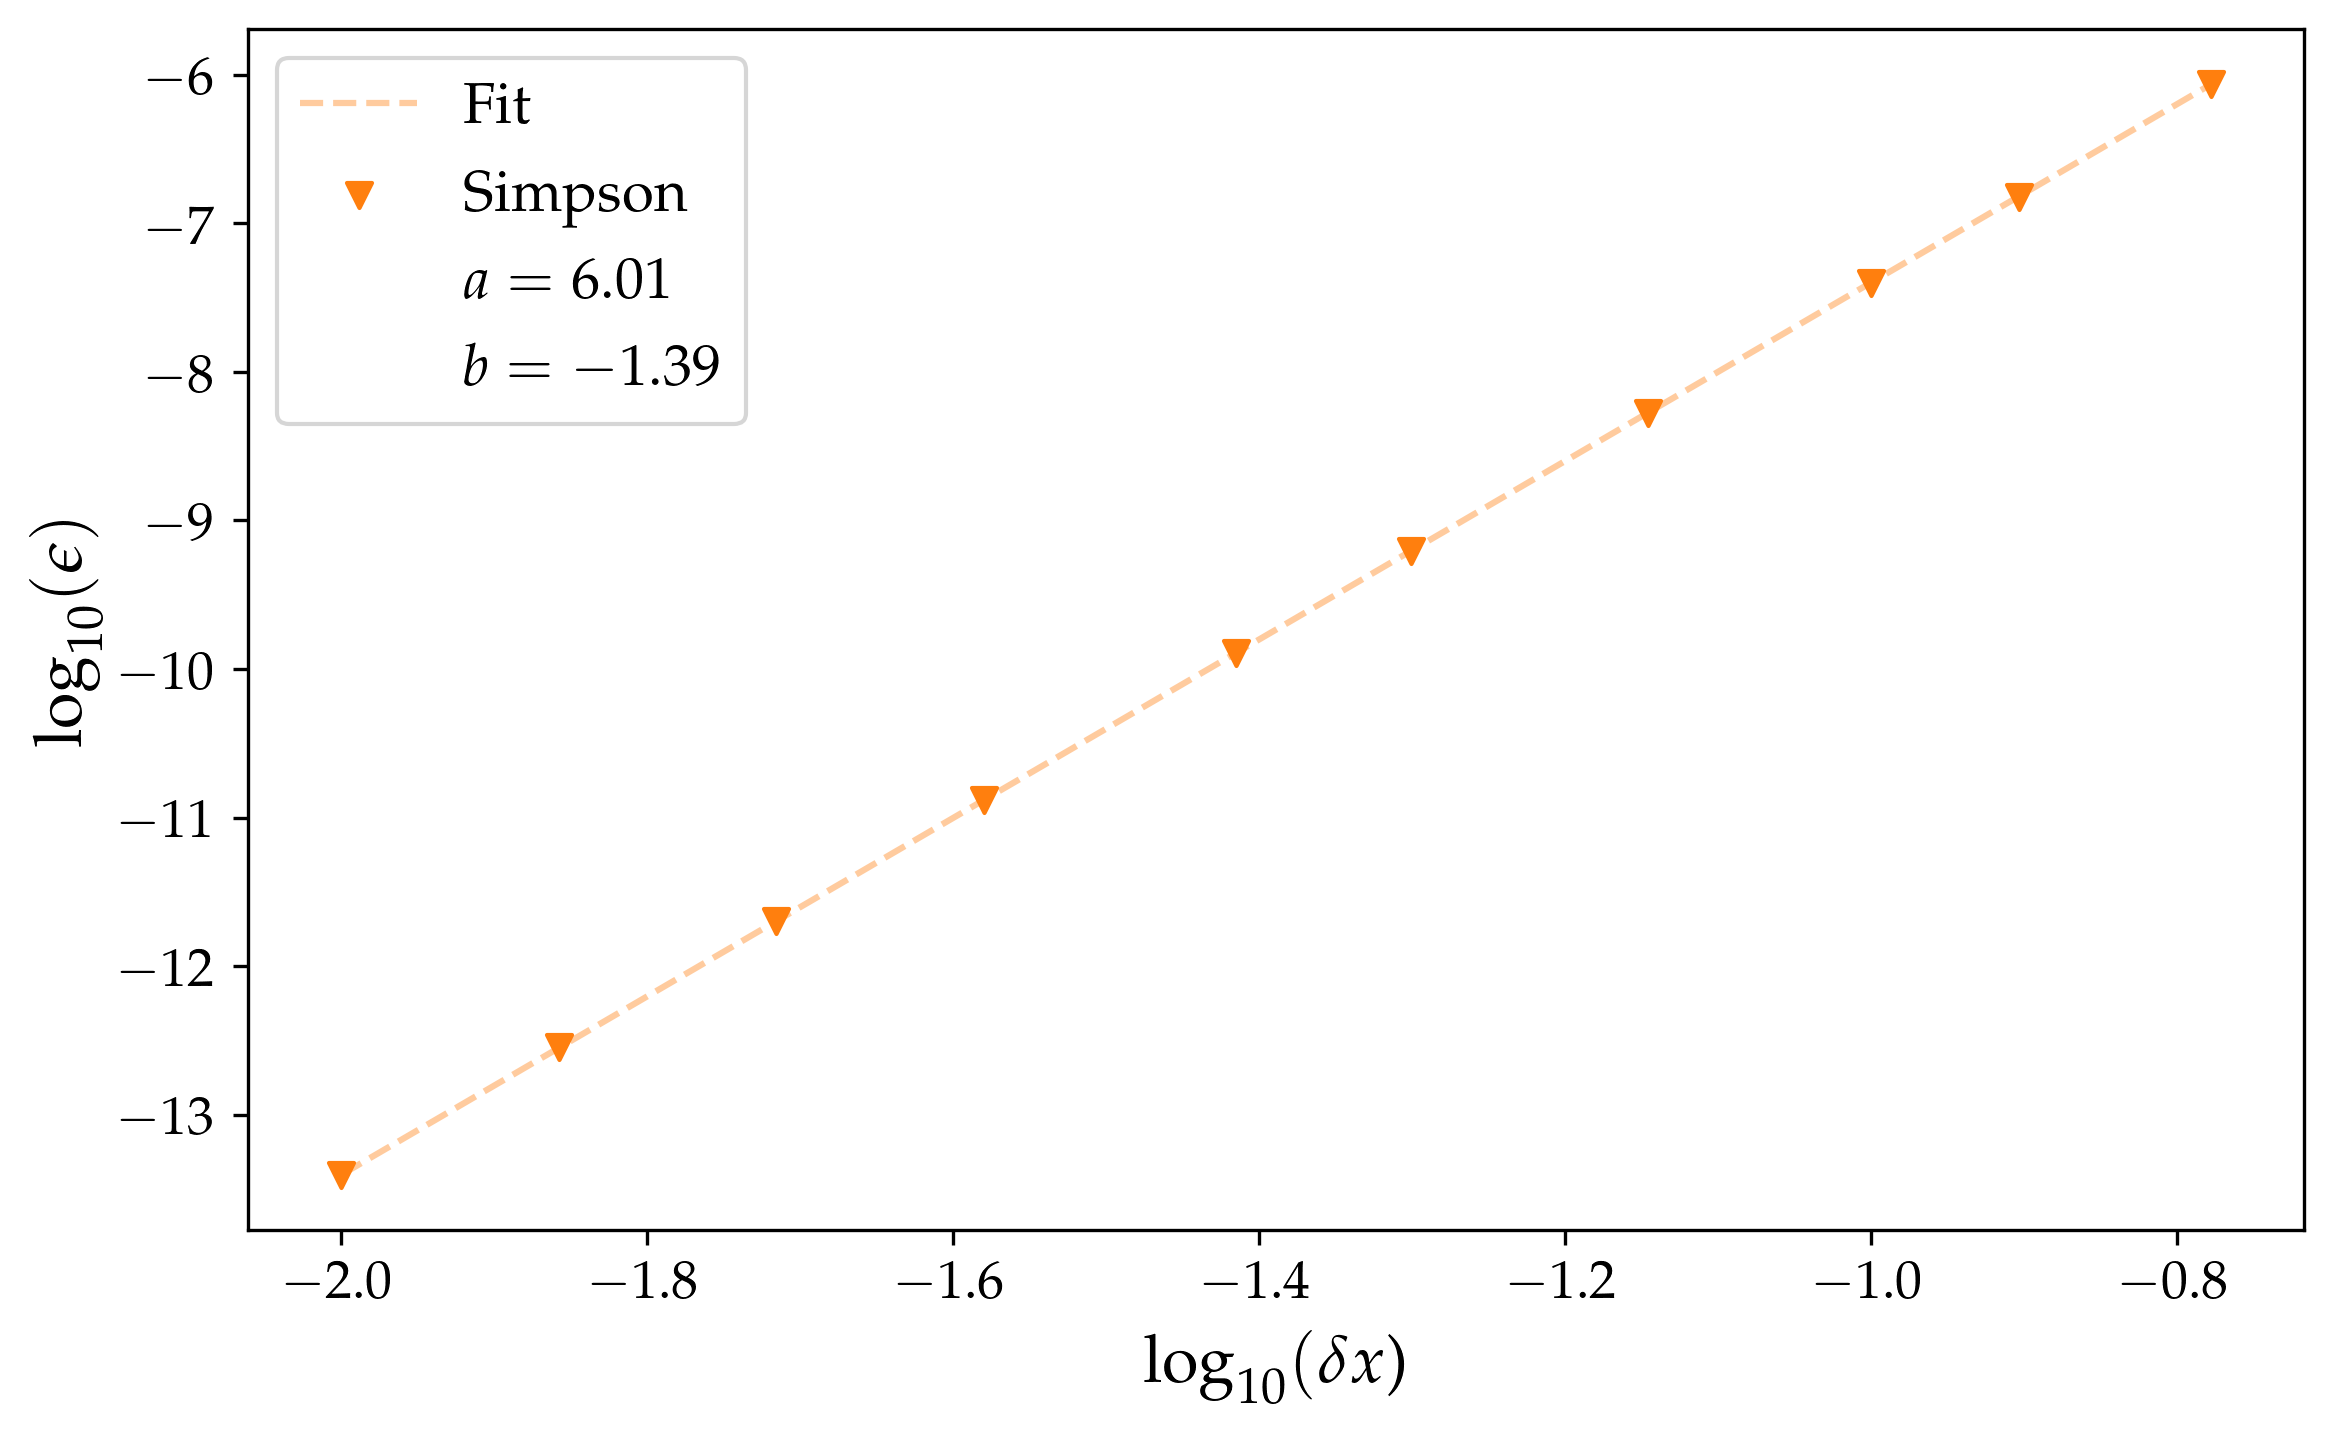

In [72]:
i = 1
cut = 35
dx, eps_dx = (true_dx[i][cut:-5], error[i][cut:-5])

res_s = lin_fit(np.log10(dx), np.log10(eps_dx),
        mar='v', col='C1', name_points='Simpson',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/FitSimp_2')

dof = 10

a = 6.02e+00 +/- 5.536e-01
b = -3.26e+00 +/- 7.183e-01

Chi2 = 0.20
p-val = 1.00


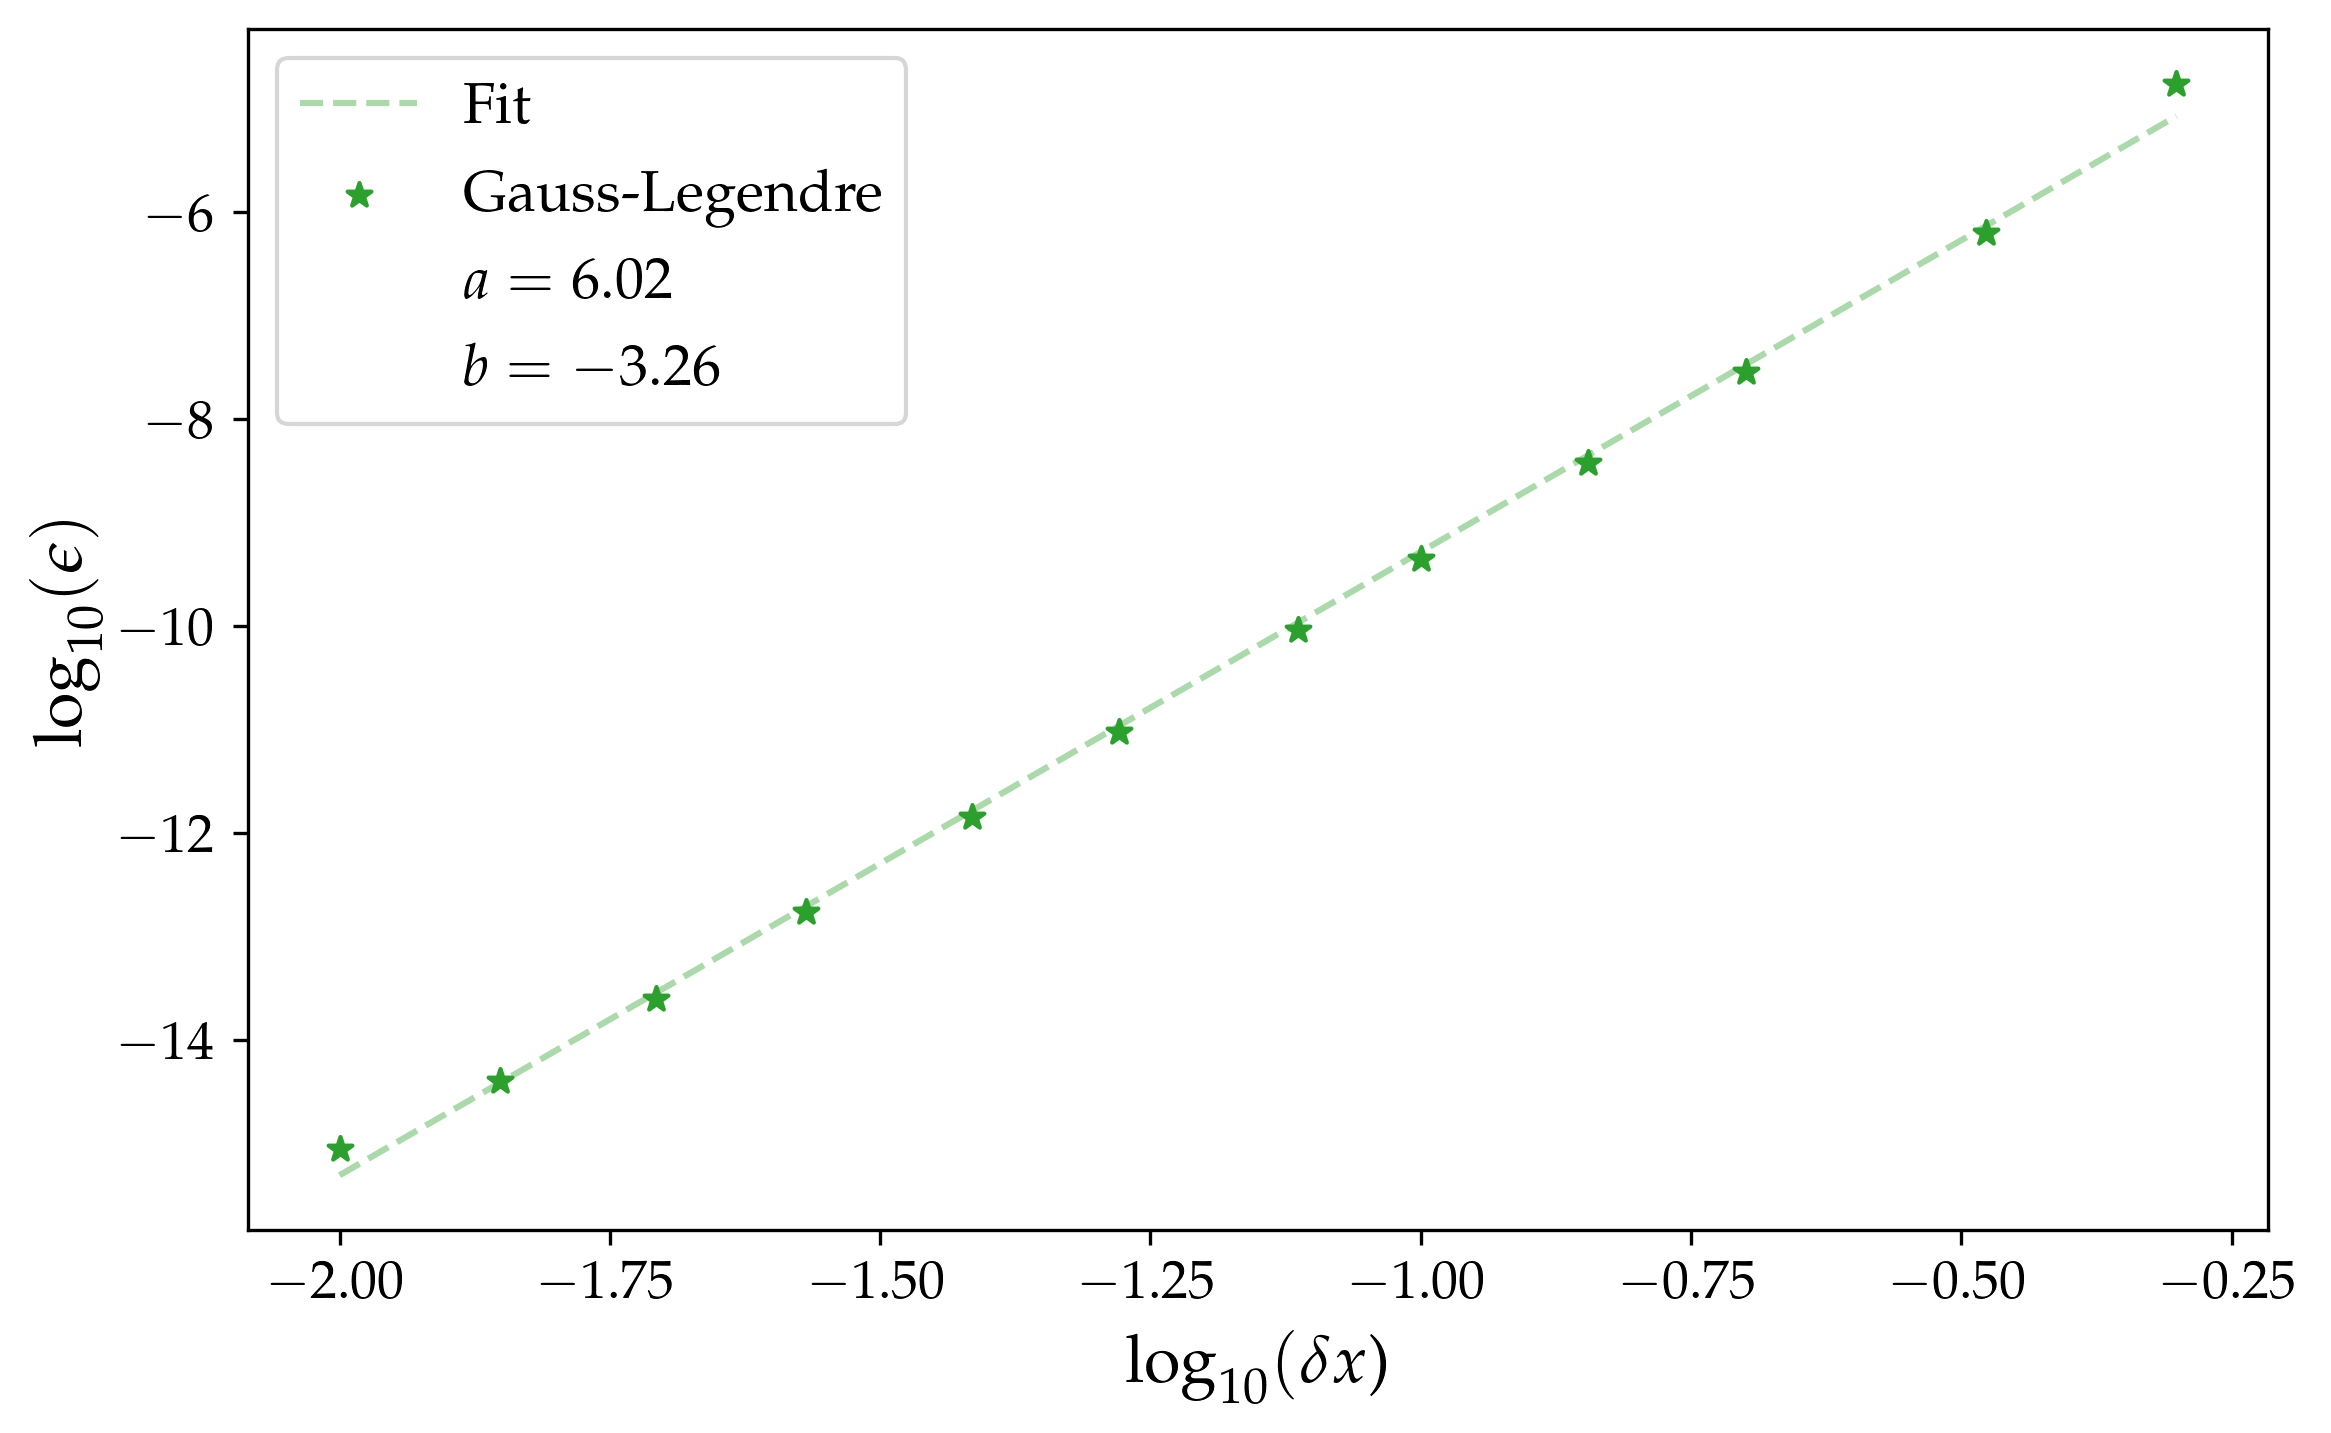

In [73]:
i = 2
cut = 35
dx, eps_dx = (true_dx[i][cut:-3], error[i][cut:-3])

res_g = lin_fit(np.log10(dx), np.log10(eps_dx),
        mar='*', col='C2', name_points='Gauss-Legendre',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/FitGauss_2')

In [74]:

p_t = res_t[0][0]
print('Expected = 2')
print(f'    p_t = {p_t}')

print()
p_s = res_s[0][0]
print('Expected = 4')
print(f'    p_s = {p_s}')

p_g = res_g[0][0]
print(f'    p_g = {p_g}')
print()

p_t, p_s, p_g = [round(p_t), round(p_s), round(p_g)]


# symbolic derivs
import sympy as sp
x_s = sp.symbols('x_s')
f_s = 4 / (1 + x_s**2)

d1f_s = sp.diff(f_s, x_s, 1) 
d3f_s = sp.diff(f_s, x_s, 3) 
d5f_s = sp.diff(f_s, x_s, 5) 

d1f = sp.lambdify(x_s, d1f_s, 'numpy')
d3f = sp.lambdify(x_s, d3f_s, 'numpy')
d5f = sp.lambdify(x_s, d5f_s, 'numpy')

x_test = np.linspace(0, 1, 1000)


ks = [1/12, 1/3780, 1/(3402 * 2**7)]
Dfs = np.abs(np.array([d1f(b) - d1f(a), d3f(b) - d3f(a), d5f(b) - d5f(a)]))

print('------------------ check ------------------')
print()
print(f'd3f(1) - d3f(0) = ({d3f(1)}) - ({d3f(0)}) = {d3f(1) - d3f(0)}')
print(f'd5f(1) - d5f(0) = ({d5f(1)}) - ({d5f(0)}) = {d5f(1) - d5f(0)}')
print()
print('-------------------------------------------')

print()

eval_N = lambda n, p, k, Df: int(np.ceil((k*Df / eps)**(1/p)/n))

eps = 1e-6
N_trap = eval_N(1, p_t, ks[0], Dfs[0])
N_simp = eval_N(2, p_s, ks[1], Dfs[2])
N_gaus = eval_N(1, p_g, ks[2], Dfs[2])

if N_simp % 2 != 0:     # for Simp N must be even
    N_simp += 1

print(f'-if Trapezoidal, p = {p_t}, n = 1, k = 1/12:')
print('     N =', N_trap)
print(f'\n-if Simpson, p = {p_s}, n = 2, k = 1/3780:')
print('     N =', N_simp)
print(f'\n-if Gauss-Legendre, p = {p_g}, n = 1, k = 1/{int(3402 * 2**7)}:')
print('     N =', N_gaus)

Expected = 2
    p_t = 1.9970176429343596

Expected = 4
    p_s = 6.0067049348684565
    p_g = 6.0223475927006165

------------------ check ------------------

d3f(1) - d3f(0) = (-0.0) - (-0.0) = 0.0
d5f(1) - d5f(0) = (60.0) - (0.0) = 60.0

-------------------------------------------

-if Trapezoidal, p = 2, n = 1, k = 1/12:
     N = 409

-if Simpson, p = 6, n = 2, k = 1/3780:
     N = 4

-if Gauss-Legendre, p = 6, n = 1, k = 1/435456:
     N = 3


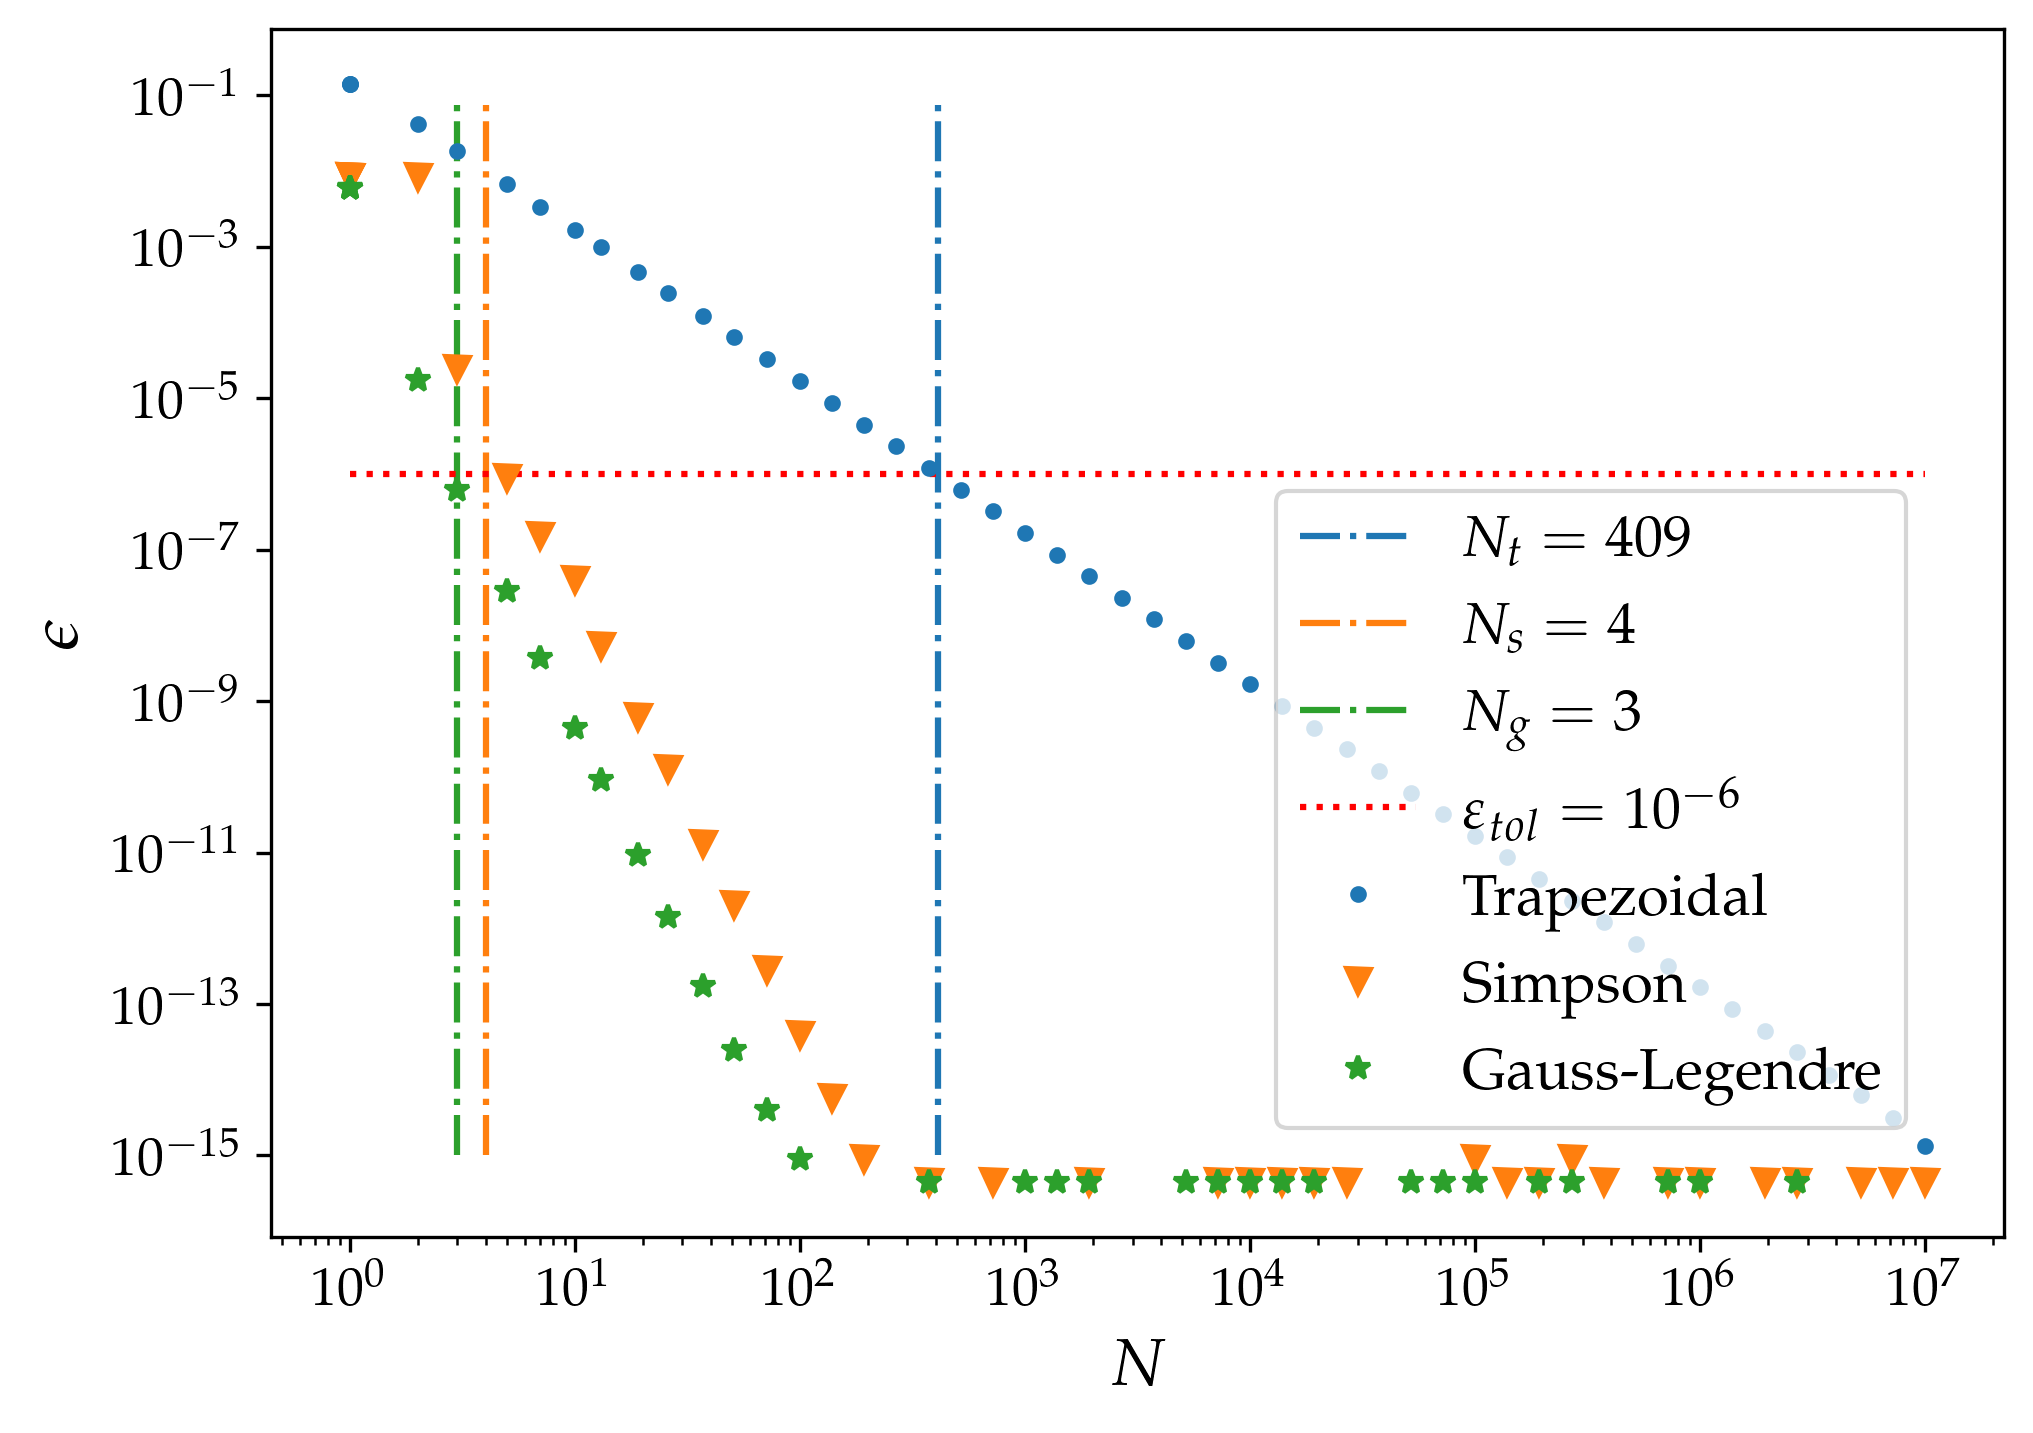

In [75]:
plt.figure(figsize=(7,5))

# N_2
plt.vlines(N_trap, 1e-15, 1e-1, color='C0', ls='-.', lw=1.5,
            label=rf'$N_t = {N_trap:.0f}$')

# N_4
len_dash = 5
ax = plt.gca()
# vl1 = plt.vlines(N_simp, 1e-15, 1e-1, color='C1', lw=2, 
#                  linestyle=(0, (len_dash, len_dash)),
#                  label=rf'$N_s = N_g = {N_simp:.0f}$')
# vl2 = plt.vlines(N_simp, 1e-15, 1e-1, color='C2', lw=2, 
#                  linestyle=(len_dash, (len_dash, len_dash)))
vl1 = plt.vlines(N_simp, 1e-15, 1e-1, color='C1', lw=1.5, 
                 ls='-.', label=rf'$N_s = {N_simp:.0f}$')
vl2 = plt.vlines(N_gaus, 1e-15, 1e-1, color='C2',
                 ls='-.', label=rf'$N_g = {N_gaus:.0f}$', lw=1.5)

# epsilon
plt.hlines(eps, np.min(N_span), np.max(N_span), color='red', ls=':',
            lw=1.5, label=r'$\varepsilon_{tol}=10^{-6}$')

for i in range(3):
    plt.loglog(N_span, error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon$')
plt.legend(loc=(0.58, 0.09))

plt.tight_layout()
plt.savefig('plots/check_prev')
plt.show()


## **Check correctness**

In [76]:
ns = (1,2,1)
N_check = (N_trap, N_simp, N_gaus)
names = ['TRAPEZOIDAL:', 'SIMPSON:', 'GAUSS-LEGENDRE:']
for n, mth in enumerate((trapezoidal, Simpson, Gauss_Leg)):
    err = abs(true - mth(func, a, b, dx=(b-a)/(ns[n]*N_check[n])))
    print(f'{names[n]}\n   e = {err:.2e}\n')


TRAPEZOIDAL:
   e = 9.96e-07

SIMPSON:
   e = 1.51e-07

GAUSS-LEGENDRE:
   e = 6.21e-07

